# Test Urban Environment

## Import Libraries

In [1]:
import sys
import os
from pathlib import Path

# Add project root to path (adjust if notebook is in a subfolder)
project_root = Path.cwd().parent  # if notebook is in experiments/ or similar
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))


import warnings

# Suppress the specific future warning from torchrl
warnings.filterwarnings(
    "ignore", 
    category=FutureWarning, 
    module="torchrl.modules.mcts.scores"
)

import torch
from torchrl.envs import EnvBase
from torchrl.data import (
    Composite, 
    Unbounded, 
    Bounded,
    Stacked
    
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

from tensordict import LazyStackedTensorDict, TensorDict, TensorDictBase
from tensordict.base import _default_is_leaf, _is_leaf_nontensor

import numpy as np

# from urbanmarl.envs.urbanmarl_env import UrbanEnv
from urbanmarl.envs.base_env import UrbanEnv

## Create Environment

In [2]:
config = {
    "num_uavs": 3,
    "num_ues": 20,
    "area_size": (500, 500),
    "max_time_slots": 50,
    "max_horizontal_speed": 49.0,
    "max_vertical_speed": 12.0,
    "max_transmit_power": 5.0,
    "frequency_ghz": 29.0,
    "g2a_bandwidth": 10e6,
    "noise_figure_db": 7.0,
    "agents": ["agent_0", "agent_1", "agent_2"]
    # "agents": ["uav_0", "uav_1", 'ue_0']
}
num_envs = 2
scenario = "uav_navigation"
# scenario = "uav_ue_los"
# scenario = "coverage"
env = UrbanEnv(
    num_envs = num_envs, # batch_size=torch.Size([2])
    continuous_actions = True,
    seed=0,
    device=device,
    scenario=scenario,
    **config)

## Test the reset method

In [3]:
# test output of reset method
tensordict = env.reset()
# tensordict.keys(True, True)

print("Shape of the reterned TensorDict:", tensordict.batch_size)
# print(f"rollout: shape: {rollout.shape}, len: {len(tensordict.shape)}")
for key in tensordict.keys(True, True):
    print(f"{key}, shape: {tensordict[key].shape}")

Shape of the reterned TensorDict: torch.Size([2])
done, shape: torch.Size([2, 1])
terminated, shape: torch.Size([2, 1])
truncated, shape: torch.Size([2, 1])
state, shape: torch.Size([2, 76])
('info', 'urban_params'), shape: torch.Size([2, 4])
('info', 'collisions'), shape: torch.Size([2, 1])
('info', 'velocity'), shape: torch.Size([2, 3])
('info', 'los'), shape: torch.Size([2, 1])
('uav', 'observation'), shape: torch.Size([2, 3, 4])


## Test reset_at method

In [4]:
# test output of reset method when passing "_reset" in input tensordict to reset_at method
tensordict = env.reset()

t = torch.zeros((env.batch_size[0], 1), dtype=torch.bool, device=env.device)
t[0,0] = True
source = {"_reset": t}
r = TensorDict(
    source=source,
    batch_size=env.batch_size,
    device=env.device,
)
env.reset(tensordict=r)

TensorDict(
    fields={
        done: Tensor(shape=torch.Size([2, 1]), device=cuda:0, dtype=torch.bool, is_shared=True),
        info: TensorDict(
            fields={
                collisions: Tensor(shape=torch.Size([2, 1]), device=cuda:0, dtype=torch.float32, is_shared=True),
                los: Tensor(shape=torch.Size([2, 1]), device=cuda:0, dtype=torch.float32, is_shared=True),
                urban_params: Tensor(shape=torch.Size([2, 4]), device=cuda:0, dtype=torch.float32, is_shared=True),
                velocity: Tensor(shape=torch.Size([2, 3]), device=cuda:0, dtype=torch.float32, is_shared=True)},
            batch_size=torch.Size([2]),
            device=cuda:0,
            is_shared=True),
        state: Tensor(shape=torch.Size([2, 76]), device=cuda:0, dtype=torch.float32, is_shared=True),
        terminated: Tensor(shape=torch.Size([2, 1]), device=cuda:0, dtype=torch.bool, is_shared=True),
        truncated: Tensor(shape=torch.Size([2, 1]), device=cuda:0, dtype=torch.b

## Test specs

In [5]:
env.check_env_specs()

2026-08-06 21:37:21,439 [torchrl][INFO]    check_env_specs succeeded! [END]


In [6]:
env._has_dynamic_specs

False

In [7]:
env.full_reward_spec_unbatched

Composite(
    uav: Composite(
        reward: UnboundedContinuous(
            shape=torch.Size([3, 1]),
            space=ContinuousBox(
                low=Tensor(shape=torch.Size([3, 1]), device=cuda:0, dtype=torch.float32, contiguous=True),
                high=Tensor(shape=torch.Size([3, 1]), device=cuda:0, dtype=torch.float32, contiguous=True)),
            device=cuda:0,
            dtype=torch.float32,
            domain=continuous),
        device=cuda:0,
        shape=torch.Size([3]),
        data_cls=None),
    device=cuda:0,
    shape=torch.Size([]),
    data_cls=None)

In [8]:
for key in env.specs.keys(True, True):
    print(key, env.specs[key].shape)

reward = env.scenario.reward(env, 'uav')
# reward = reward.mean(dim=1)
reward, reward.shapef

('output_spec', 'full_observation_spec', 'uav', 'observation') torch.Size([2, 3, 4])
('output_spec', 'full_observation_spec', 'state') torch.Size([2, 76])
('output_spec', 'full_observation_spec', 'info', 'urban_params') torch.Size([2, 4])
('output_spec', 'full_observation_spec', 'info', 'collisions') torch.Size([2, 1])
('output_spec', 'full_observation_spec', 'info', 'velocity') torch.Size([2, 3])
('output_spec', 'full_observation_spec', 'info', 'los') torch.Size([2, 1])
('output_spec', 'full_reward_spec', 'uav', 'reward') torch.Size([2, 3, 1])
('output_spec', 'full_done_spec', 'done') torch.Size([2, 1])
('output_spec', 'full_done_spec', 'terminated') torch.Size([2, 1])
('output_spec', 'full_done_spec', 'truncated') torch.Size([2, 1])
('input_spec', 'full_action_spec', 'uav', 'action') torch.Size([2, 3, 3])


(tensor([[[0.2500],
          [0.4500],
          [0.0500]],
 
         [[0.7500],
          [0.5000],
          [0.6000]]], device='cuda:0'),
 torch.Size([2, 3, 1]))

In [9]:
env.specs

Composite(
    output_spec: Composite(
        full_observation_spec: Composite(
            uav: Composite(
                observation: BoundedContinuous(
                    shape=torch.Size([2, 3, 4]),
                    space=ContinuousBox(
                        low=Tensor(shape=torch.Size([2, 3, 4]), device=cuda:0, dtype=torch.float32, contiguous=True),
                        high=Tensor(shape=torch.Size([2, 3, 4]), device=cuda:0, dtype=torch.float32, contiguous=True)),
                    device=cuda:0,
                    dtype=torch.float32,
                    domain=continuous),
                device=cuda:0,
                shape=torch.Size([2, 3]),
                data_cls=None),
            state: UnboundedContinuous(
                shape=torch.Size([2, 76]),
                space=ContinuousBox(
                    low=Tensor(shape=torch.Size([2, 76]), device=cuda:0, dtype=torch.float32, contiguous=True),
                    high=Tensor(shape=torch.Size([2, 76]), dev

In [10]:
print("action_spec:", env.full_action_spec)
print("reward_spec:", env.full_reward_spec)
print("done_spec:", env.full_done_spec)
print("observation_spec:", env.observation_spec)

action_spec: Composite(
    uav: Composite(
        action: BoundedContinuous(
            shape=torch.Size([2, 3, 3]),
            space=ContinuousBox(
                low=Tensor(shape=torch.Size([2, 3, 3]), device=cuda:0, dtype=torch.float32, contiguous=True),
                high=Tensor(shape=torch.Size([2, 3, 3]), device=cuda:0, dtype=torch.float32, contiguous=True)),
            device=cuda:0,
            dtype=torch.float32,
            domain=continuous),
        device=cuda:0,
        shape=torch.Size([2, 3]),
        data_cls=None),
    device=cuda:0,
    shape=torch.Size([2]),
    data_cls=None)
reward_spec: Composite(
    uav: Composite(
        reward: UnboundedContinuous(
            shape=torch.Size([2, 3, 1]),
            space=ContinuousBox(
                low=Tensor(shape=torch.Size([2, 3, 1]), device=cuda:0, dtype=torch.float32, contiguous=True),
                high=Tensor(shape=torch.Size([2, 3, 1]), device=cuda:0, dtype=torch.float32, contiguous=True)),
          

## Test Rollout

For fun, let’s see what a simple random rollout looks like. You can call env.rollout(n_steps) and get an overview of what the environment inputs and outputs look like. Actions will automatically be drawn at random from the action spec domain.


In [11]:
n_rollout_steps = 3
rollout = env.rollout(n_rollout_steps)

print("Shape of the rollout TensorDict:", rollout.batch_size)
print(f"rollout: shape: {rollout.shape}, len: {len(rollout.shape)}")
for key in rollout.keys(True, True):
    print(f"{key}, shape: {rollout[key].shape}")
    

Shape of the rollout TensorDict: torch.Size([2, 3])
rollout: shape: torch.Size([2, 3]), len: 2
done, shape: torch.Size([2, 3, 1])
terminated, shape: torch.Size([2, 3, 1])
truncated, shape: torch.Size([2, 3, 1])
state, shape: torch.Size([2, 3, 76])
('info', 'urban_params'), shape: torch.Size([2, 3, 4])
('info', 'collisions'), shape: torch.Size([2, 3, 1])
('info', 'velocity'), shape: torch.Size([2, 3, 3])
('info', 'los'), shape: torch.Size([2, 3, 1])
('uav', 'observation'), shape: torch.Size([2, 3, 3, 4])
('uav', 'action'), shape: torch.Size([2, 3, 3, 3])
('next', 'done'), shape: torch.Size([2, 3, 1])
('next', 'terminated'), shape: torch.Size([2, 3, 1])
('next', 'truncated'), shape: torch.Size([2, 3, 1])
('next', 'state'), shape: torch.Size([2, 3, 76])
('next', 'info', 'urban_params'), shape: torch.Size([2, 3, 4])
('next', 'info', 'collisions'), shape: torch.Size([2, 3, 1])
('next', 'info', 'velocity'), shape: torch.Size([2, 3, 3])
('next', 'info', 'los'), shape: torch.Size([2, 3, 1])
('

In [12]:
assert rollout["done"].shape == torch.Size((env.batch_size[0], n_rollout_steps, 1)), f"{rollout["done"].shape} not equal {torch.Size((env.batch_size[0], n_rollout_steps, 1))}"

## Test step

In [13]:
action = env.action_spec.sample()
print(action.keys(True, True))
for group in env.group_map:
    print(action.get((group, 'action')))

_TensorDictKeysView([('uav', 'action')],
    include_nested=True,
    leaves_only=True)
tensor([[[ 30.6643,  -2.9030,  11.4373],
         [ 41.7603,   0.8107,  -9.3837],
         [ 12.9224,   2.1658,   1.7538]],

        [[ 18.8934,   2.1517,   0.2456],
         [-22.5889,  -0.6916,   9.1413],
         [ 33.1230,   0.5236,   2.1743]]], device='cuda:0')


In [14]:
action = env.action_spec.sample()
new_td = tensordict.update(action)
next_td = env.step(new_td)

print(f"next_td: {next_td.shape}, len: {len(next_td.shape)}")
for key in next_td.keys(True, True):
    print(f"{key} shape: {next_td[key].shape}")

next_td: torch.Size([2]), len: 1
done shape: torch.Size([2, 1])
terminated shape: torch.Size([2, 1])
truncated shape: torch.Size([2, 1])
state shape: torch.Size([2, 76])
('info', 'urban_params') shape: torch.Size([2, 4])
('info', 'collisions') shape: torch.Size([2, 1])
('info', 'velocity') shape: torch.Size([2, 3])
('info', 'los') shape: torch.Size([2, 1])
('uav', 'observation') shape: torch.Size([2, 3, 4])
('uav', 'action') shape: torch.Size([2, 3, 3])
('next', 'done') shape: torch.Size([2, 1])
('next', 'terminated') shape: torch.Size([2, 1])
('next', 'truncated') shape: torch.Size([2, 1])
('next', 'state') shape: torch.Size([2, 76])
('next', 'info', 'urban_params') shape: torch.Size([2, 4])
('next', 'info', 'collisions') shape: torch.Size([2, 1])
('next', 'info', 'velocity') shape: torch.Size([2, 3])
('next', 'info', 'los') shape: torch.Size([2, 1])
('next', 'uav', 'observation') shape: torch.Size([2, 3, 4])
('next', 'uav', 'reward') shape: torch.Size([2, 3, 1])


In [15]:
next_td.keys(True, True, sort=True)
for group in env.group_map.keys():
    print(next_td.get(("next", group)).keys())
    assert "reward" in next_td.get(("next", group)).keys()

_StringKeys(dict_keys(['observation', 'reward']))


In [16]:
for key in next_td.keys(True, True):
    print(f"{key}, size: {next_td[key].shape}")

done, size: torch.Size([2, 1])
terminated, size: torch.Size([2, 1])
truncated, size: torch.Size([2, 1])
state, size: torch.Size([2, 76])
('info', 'urban_params'), size: torch.Size([2, 4])
('info', 'collisions'), size: torch.Size([2, 1])
('info', 'velocity'), size: torch.Size([2, 3])
('info', 'los'), size: torch.Size([2, 1])
('uav', 'observation'), size: torch.Size([2, 3, 4])
('uav', 'action'), size: torch.Size([2, 3, 3])
('next', 'done'), size: torch.Size([2, 1])
('next', 'terminated'), size: torch.Size([2, 1])
('next', 'truncated'), size: torch.Size([2, 1])
('next', 'state'), size: torch.Size([2, 76])
('next', 'info', 'urban_params'), size: torch.Size([2, 4])
('next', 'info', 'collisions'), size: torch.Size([2, 1])
('next', 'info', 'velocity'), size: torch.Size([2, 3])
('next', 'info', 'los'), size: torch.Size([2, 1])
('next', 'uav', 'observation'), size: torch.Size([2, 3, 4])
('next', 'uav', 'reward'), size: torch.Size([2, 3, 1])


## Check inheretence

In [17]:
UrbanEnv.__mro__

(urbanmarl.envs.base_env.UrbanEnv,
 urbanmarl.envs.base_env.UrbanEnvBase,
 torchrl.envs.common._EnvWrapper,
 torchrl.envs.common.EnvBase,
 torch.nn.modules.module.Module,
 object)

In [18]:
env.reset()

TensorDict(
    fields={
        done: Tensor(shape=torch.Size([2, 1]), device=cuda:0, dtype=torch.bool, is_shared=True),
        info: TensorDict(
            fields={
                collisions: Tensor(shape=torch.Size([2, 1]), device=cuda:0, dtype=torch.float32, is_shared=True),
                los: Tensor(shape=torch.Size([2, 1]), device=cuda:0, dtype=torch.float32, is_shared=True),
                urban_params: Tensor(shape=torch.Size([2, 4]), device=cuda:0, dtype=torch.float32, is_shared=True),
                velocity: Tensor(shape=torch.Size([2, 3]), device=cuda:0, dtype=torch.float32, is_shared=True)},
            batch_size=torch.Size([2]),
            device=cuda:0,
            is_shared=True),
        state: Tensor(shape=torch.Size([2, 76]), device=cuda:0, dtype=torch.float32, is_shared=True),
        terminated: Tensor(shape=torch.Size([2, 1]), device=cuda:0, dtype=torch.bool, is_shared=True),
        truncated: Tensor(shape=torch.Size([2, 1]), device=cuda:0, dtype=torch.b

## Plot Urban Map Example

<Axes: title={'center': 'Procedural Urban Map Height Profile\n(alpha=0.66, beta=351.0, gamma=10.0)'}, xlabel='X Coordinate', ylabel='Y Coordinate'>

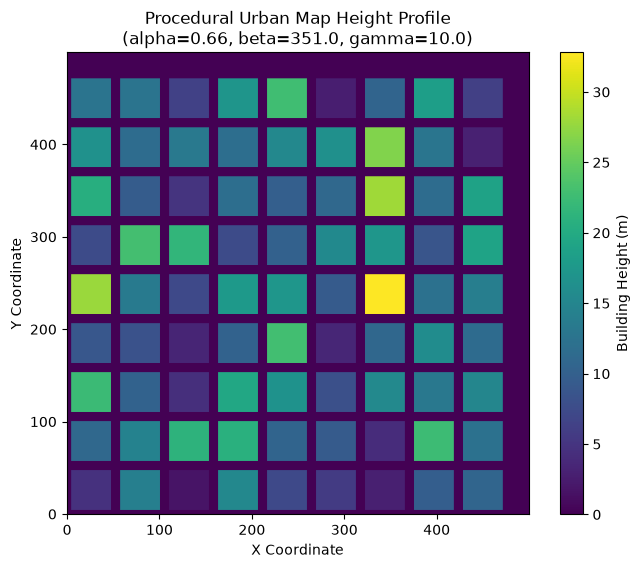

In [19]:
env._env.plot(batch_idx = 1)

## Test 3D rendering

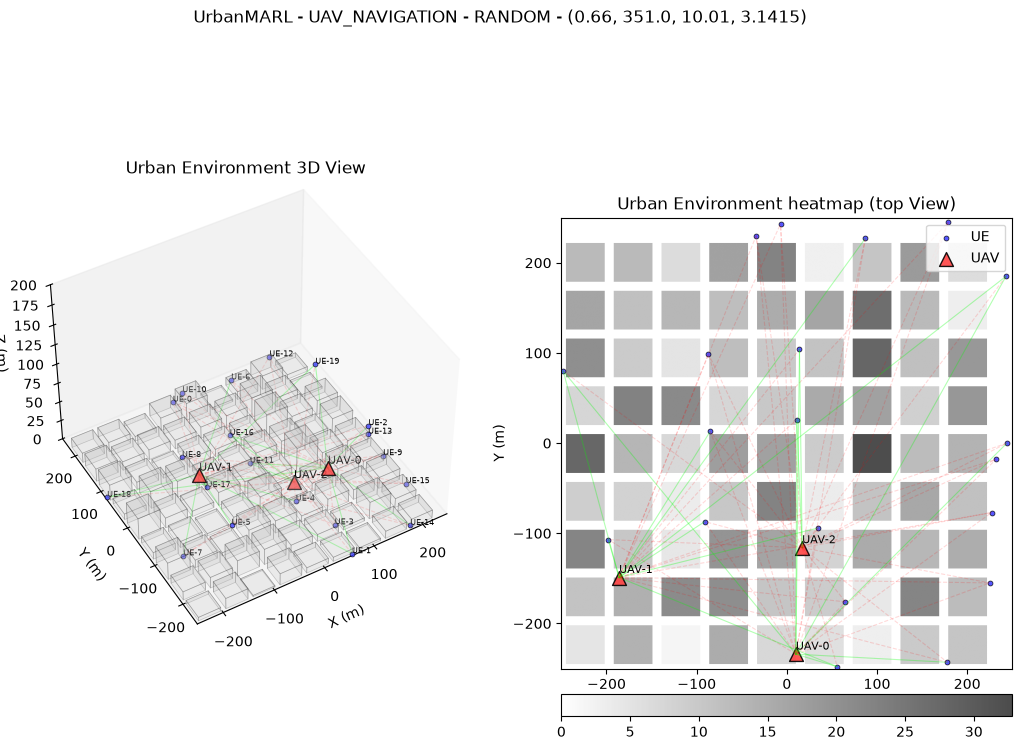

In [20]:
img = env.scenario.render(env, mode='human')